# 🧠 Dermatology AI Intelligence System

### Automated Skin Lesion Classification and Segmentation

**Author:** Manikant  
**Program:** B.Tech CSE (AI & ML)  
**University:** Sharda University  

---

### Project Phases

- **Phase 1:** Skin Lesion Classification (HAM10000 Dataset)
- **Phase 2:** Lesion Segmentation (ISIC 2018 Dataset)
- **Phase 3:** ROI-based Classification (Upcoming)

---

# 📌 Project Overview

Skin cancer is one of the most common cancers worldwide. Early detection significantly improves treatment outcomes.  

This project develops an **AI-based dermatology intelligence system** capable of:

- Classifying different types of skin lesions
- Segmenting lesion regions from dermoscopic images
- Improving classification accuracy using segmentation-based ROI extraction

The system uses **deep learning models** trained on publicly available dermatology datasets.

# 🎯 Problem Statement

Skin cancer diagnosis using dermoscopic images is challenging and requires expert dermatologists.  
Manual analysis can be time-consuming and subjective.

The goal of this project is to develop an **AI-powered dermatology system** capable of:

- Automatically classifying skin lesions
- Detecting lesion regions through segmentation
- Improving classification accuracy using region-focused analysis

# 📂 Datasets Used

### HAM10000 Dataset
- 10,015 dermoscopic images
- 7 classes of skin lesions
- Used for **classification**

### ISIC 2018 Dataset
- Dermoscopic images with segmentation masks
- Used for **lesion segmentation**

In [9]:
# ==============================
#  DERMATOLOGY AI PROJECT SETUP
# ==============================

import os
import zipfile
import numpy as np
import tensorflow as tf
from google.colab import drive

print("Mounting Google Drive...")
drive.mount('/content/drive')

# Define project path
PROJECT_PATH = "/content/drive/MyDrive/Dermatology_AI_Project"
DATASET_PATH = f"{PROJECT_PATH}/datasets"

# ZIP file paths
ISIC_ZIP = f"{DATASET_PATH}/ISIC2018_segmentation.zip"
HAM_ZIP = f"{DATASET_PATH}/HAM10000.zip"

print("Project Path:", PROJECT_PATH)
print("Dataset Path:", DATASET_PATH)

# Move to project directory
os.chdir(PROJECT_PATH)
print("Current Working Directory:", os.getcwd())

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project Path: /content/drive/MyDrive/Dermatology_AI_Project
Dataset Path: /content/drive/MyDrive/Dermatology_AI_Project/datasets
Current Working Directory: /content/drive/MyDrive/Dermatology_AI_Project


In [ ]:

#  Copy datasets to runtime

print("Copying datasets to /content ...")

!cp "$ISIC_ZIP" /content/
!cp "$HAM_ZIP" /content/

print("Done copying.")

Copying datasets to /content ...
Done copying.


In [ ]:

#  Unzip datasets

%cd /content

print("Extracting ISIC dataset...")
!unzip -q ISIC2018_segmentation.zip

print("Extracting HAM10000 dataset...")
!unzip -q HAM10000.zip

print("Extraction complete.")

/content
Extracting ISIC dataset...
Extracting HAM10000 dataset...
Extraction complete.


In [ ]:

#  Define dataset paths


# ISIC Segmentation Paths
ISIC_TRAIN_IMAGES = "/content/ISIC2018_Task1-2_Training_Input"
ISIC_TRAIN_MASKS = "/content/ISIC2018_Task1_Training_GroundTruth"

# HAM10000 Paths
HAM_IMAGES_PART1 = "/content/HAM10000_images_part_1"
HAM_IMAGES_PART2 = "/content/HAM10000_images_part_2"
HAM_METADATA = "/content/HAM10000_metadata.csv"

print("ISIC Train Images:", ISIC_TRAIN_IMAGES)
print("ISIC Train Masks:", ISIC_TRAIN_MASKS)
print("HAM Metadata:", HAM_METADATA)

ISIC Train Images: /content/ISIC2018_Task1-2_Training_Input
ISIC Train Masks: /content/ISIC2018_Task1_Training_GroundTruth
HAM Metadata: /content/HAM10000_metadata.csv


In [ ]:

# 🔎 Sanity Check


print("ISIC Images Count:", len(os.listdir(ISIC_TRAIN_IMAGES)))
print("ISIC Masks Count:", len(os.listdir(ISIC_TRAIN_MASKS)))

print("HAM Part1 Count:", len(os.listdir(HAM_IMAGES_PART1)))
print("HAM Part2 Count:", len(os.listdir(HAM_IMAGES_PART2)))

ISIC Images Count: 2596
ISIC Masks Count: 2596
HAM Part1 Count: 5000
HAM Part2 Count: 5015


In [ ]:
print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import os

PROJECT_PATH = "/content/drive/MyDrive/Dermatology_AI_Project"

# Create folders if they don't exist
os.makedirs(f"{PROJECT_PATH}/models", exist_ok=True)
os.makedirs(f"{PROJECT_PATH}/results", exist_ok=True)
os.makedirs(f"{PROJECT_PATH}/notebooks", exist_ok=True)

print("Folders created successfully.")
print(os.listdir(PROJECT_PATH))

Folders created successfully.
['kaggle.json', 'datasets', 'models', 'results', 'notebooks']


In [ ]:
!pip install kaggle opencv-python tqdm

In [ ]:
!mkdir -p ~/.kaggle
!cp "{PROJECT_PATH}/kaggle.json" ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets list | head

ref                                                             title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
amar5693/screen-time-sleep-and-stress-analysis-dataset          Screen Time, Sleep & Stress Analysis Dataset            787136  2026-02-13 06:56:18.757000           9756        189  1.0              
amar5693/student-performance-dataset                            Student Performance Dataset                             177286  2026-02-12 06:04:44.613000           8292        134  1.0              
aliiihussain/amazon-sales-dataset                               Amazon_Sales_Dataset                                   1297759  2026-02-01 11:37:12.353000           9993        149  1.0              


# =========================================
# 🔹 PHASE 1 – SKIN LESION CLASSIFICATION
# =========================================

Model: MobileNetV2  
Dataset: HAM10000  
Objective: Classify dermoscopic images into 7 skin lesion categories.

## Model Architecture – MobileNetV2

MobileNetV2 is a lightweight convolutional neural network designed for efficient image classification.

Key features:
- Depthwise separable convolutions
- Inverted residual blocks
- Low computational cost

This makes it suitable for medical image classification tasks.

In [ ]:
import os
print("Current Directory:", os.getcwd())

Current Directory: /content


In [ ]:
os.listdir("/content")

['.config',
 'hmnist_8_8_L.csv',
 'HAM10000_images_part_1',
 'HAM10000.zip',
 'ham10000_images_part_2',
 'HAM10000_images_part_2',
 'ISIC2018_segmentation.zip',
 'drive',
 'HAM10000_metadata.csv',
 'hmnist_8_8_RGB.csv',
 'ISIC2018_Task1-2_Training_Input',
 'ham10000_images_part_1',
 'hmnist_28_28_RGB.csv',
 'ISIC2018_Task1_Training_GroundTruth',
 'ISIC2018_Task1-2_Validation_Input',
 'ISIC2018_Task1-2_Test_Input',
 'hmnist_28_28_L.csv',
 'sample_data']

In [ ]:
import pandas as pd

metadata = pd.read_csv("/content/HAM10000_metadata.csv")
metadata.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [ ]:
import os

image_path_dict = {}

for folder in ["HAM10000_images_part_1", "HAM10000_images_part_2"]:
    folder_path = os.path.join("/content", folder)
    for img in os.listdir(folder_path):
        image_id = img.split(".")[0]
        image_path_dict[image_id] = os.path.join(folder_path, img)

# Add paths to dataframe
metadata["path"] = metadata["image_id"].map(image_path_dict.get)

metadata.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/content/HAM10000_images_part_1/ISIC_0027419.jpg
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/content/HAM10000_images_part_1/ISIC_0025030.jpg
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/content/HAM10000_images_part_1/ISIC_0026769.jpg
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/content/HAM10000_images_part_1/ISIC_0025661.jpg
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/content/HAM10000_images_part_2/ISIC_0031633.jpg


In [ ]:
print("Missing paths:", metadata["path"].isnull().sum())

Missing paths: 0


In [ ]:
metadata["dx"].value_counts()

,count
dx,
nv,6705
mel,1113
bkl,1099
bcc,514
akiec,327
vasc,142
df,115


In [ ]:
from sklearn.model_selection import train_test_split

# First split: train + temp
train_df, temp_df = train_test_split(
    metadata,
    test_size=0.2,
    stratify=metadata["dx"],
    random_state=42
)

# Second split: val + test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["dx"],
    random_state=42
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (8012, 8)
Validation: (1001, 8)
Test: (1002, 8)


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Get class labels from training data
classes = np.unique(train_df['dx'])

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_df['dx']
)

# Convert to dictionary
class_weights_dict = dict(zip(classes, class_weights))

print(class_weights_dict)

{'akiec': np.float64(4.368593238822246), 'bcc': np.float64(2.7848453249913105), 'bkl': np.float64(1.3021290427433772), 'df': np.float64(12.440993788819876), 'mel': np.float64(1.2860353130016051), 'nv': np.float64(0.21338020666879728), 'vasc': np.float64(10.040100250626567)}


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col="path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical"
)

val_generator = val_datagen.flow_from_dataframe(
    val_df,
    x_col="path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical"
)

test_generator = val_datagen.flow_from_dataframe(
    test_df,
    x_col="path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 8012 validated image filenames belonging to 7 classes.
Found 1001 validated image filenames belonging to 7 classes.
Found 1002 validated image filenames belonging to 7 classes.


In [ ]:
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(8012, 8)
(1001, 8)
(1002, 8)


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base model
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
predictions = Dense(7, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,266,951 (8.65 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
import tensorflow as tf

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/Dermatology_AI_Project/models/mobilenet_best.h5",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights_dict,
    callbacks=[early_stop, checkpoint]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 734ms/step - accuracy: 0.4631 - loss: 1.5930

251/251 ━━━━━━━━━━━━━━━━━━━━ 245s 842ms/step - accuracy: 0.4636 - loss: 1.5919 - val_accuracy: 0.6743 - val_loss: 1.0014
Epoch 2/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 552ms/step - accuracy: 0.6481 - loss: 1.1396

251/251 ━━━━━━━━━━━━━━━━━━━━ 146s 583ms/step - accuracy: 0.6481 - loss: 1.1394 - val_accuracy: 0.6893 - val_loss: 0.9387
Epoch 3/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 555ms/step - accuracy: 0.6645 - loss: 1.0012

251/251 ━━━━━━━━━━━━━━━━━━━━ 202s 583ms/step - accuracy: 0.6645 - loss: 1.0013 - val_accuracy: 0.6933 - val_loss: 0.8877
Epoch 4/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 560ms/step - accuracy: 0.6661 - loss: 0.9991

...

251/251 ━━━━━━━━━━━━━━━━━━━━ 144s 574ms/step - accuracy: 0.6984 - loss: 0.8766 - val_accuracy: 0.7023 - val_loss: 0.8130
Epoch 8/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 541ms/step - accuracy: 0.7067 - loss: 0.8596

251/251 ━━━━━━━━━━━━━━━━━━━━ 144s 575ms/step - accuracy: 0.7066 - loss: 0.8596 - val_accuracy: 0.7103 - val_loss: 0.8038
Epoch 9/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 142s 567ms/step - accuracy: 0.7041 - loss: 0.8565 - val_accuracy: 0.7083 - val_loss: 0.7888
Epoch 10/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 142s 567ms/step - accuracy: 0.7023 - loss: 0.8646 - val_accuracy: 0.7093 - val_loss: 0.7830
Epoch 11/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 562ms/step - accuracy: 0.7127 - loss: 0.8157

251/251 ━━━━━━━━━━━━━━━━━━━━ 150s 597ms/step - accuracy: 0.7127 - loss: 0.8157 - val_accuracy: 0.7143 - val_loss: 0.7763
Epoch 12/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 147s 585ms/step - accuracy: 0.7059 - loss: 0.8159 - val_accuracy: 0.7143 - val_loss: 0.7778
Epoch 13/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 561ms/step - accuracy: 0.7214 - loss: 0.8052

251/251 ━━━━━━━━━━━━━━━━━━━━ 150s 597ms/step - accuracy: 0.7214 - loss: 0.8052 - val_accuracy: 0.7223 - val_loss: 0.7654
Epoch 14/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 146s 583ms/step - accuracy: 0.7192 - loss: 0.8140 - val_accuracy: 0.7193 - val_loss: 0.7632
Epoch 15/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 148s 591ms/step - accuracy: 0.7275 - loss: 0.7803 - val_accuracy: 0.7183 - val_loss: 0.7659
Epoch 16/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 153s 608ms/step - accuracy: 0.7125 - loss: 0.8130 - val_accuracy: 0.7183 - val_loss: 0.7553
Epoch 17/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 582ms/step - accuracy: 0.7139 - loss: 0.7998

251/251 ━━━━━━━━━━━━━━━━━━━━ 204s 618ms/step - accuracy: 0.7139 - loss: 0.7997 - val_accuracy: 0.7233 - val_loss: 0.7497
Epoch 18/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 150s 597ms/step - accuracy: 0.7277 - loss: 0.7677 - val_accuracy: 0.7223 - val_loss: 0.7494
Epoch 19/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 146s 579ms/step - accuracy: 0.7275 - loss: 0.7696 - val_accuracy: 0.7223 - val_loss: 0.7427
Epoch 20/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 145s 579ms/step - accuracy: 0.7233 - loss: 0.7684 - val_accuracy: 0.7233 - val_loss: 0.7509


In [ ]:
test_loss, test_acc = model.evaluate(test_generator)
print("Test Accuracy:", test_acc)

32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 670ms/step - accuracy: 0.7224 - loss: 0.7775
Test Accuracy: 0.7375249266624451


In [ ]:
import os
os.listdir("/content/drive/MyDrive/Dermatology_AI_Project/models")

['mobilenet_best.h5']

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/Dermatology_AI_Project/models/mobilenet_best.h5")

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,266,953 (8.65 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 2 (12.00 B)

In [ ]:
# Unfreeze last 30 layers
for layer in model.layers[-30:]:
    layer.trainable = True

# Keep earlier layers frozen
for layer in model.layers[:-30]:
    layer.trainable = False

In [ ]:
print("Trainable layers:")
print(sum([layer.trainable for layer in model.layers]))

Trainable layers:
30


In [ ]:
import tensorflow as tf

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

early_stop_ft = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    verbose=1
)

checkpoint_ft = ModelCheckpoint(
    "/content/drive/MyDrive/Dermatology_AI_Project/models/mobilenet_finetuned.h5",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

In [ ]:
history_ft = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=8,
    class_weight=class_weights_dict,
    callbacks=[early_stop_ft, reduce_lr, checkpoint_ft]
)

Epoch 1/8
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 582ms/step - accuracy: 0.6311 - loss: 1.0460

251/251 ━━━━━━━━━━━━━━━━━━━━ 179s 648ms/step - accuracy: 0.6313 - loss: 1.0457 - val_accuracy: 0.7293 - val_loss: 0.7807 - learning_rate: 1.0000e-05
Epoch 2/8
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 549ms/step - accuracy: 0.7108 - loss: 0.8437

251/251 ━━━━━━━━━━━━━━━━━━━━ 145s 578ms/step - accuracy: 0.7107 - loss: 0.8437 - val_accuracy: 0.7353 - val_loss: 0.8127 - learning_rate: 1.0000e-05
Epoch 3/8
251/251 ━━━━━━━━━━━━━━━━━━━━ 146s 581ms/step - accuracy: 0.7144 - loss: 0.8038 - val_accuracy: 0.7293 - val_loss: 0.7795 - learning_rate: 1.0000e-05
Epoch 4/8
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 557ms/step - accuracy: 0.7298 - loss: 0.7580

251/251 ━━━━━━━━━━━━━━━━━━━━ 147s 586ms/step - accuracy: 0.7298 - loss: 0.7580 - val_accuracy: 0.7413 - val_loss: 0.7534 - learning_rate: 1.0000e-05
Epoch 5/8
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 562ms/step - accuracy: 0.7427 - loss: 0.7142

251/251 ━━━━━━━━━━━━━━━━━━━━ 149s 594ms/step - accuracy: 0.7427 - loss: 0.7143 - val_accuracy: 0.7423 - val_loss: 0.7268 - learning_rate: 1.0000e-05
Epoch 6/8
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 555ms/step - accuracy: 0.7507 - loss: 0.7018

251/251 ━━━━━━━━━━━━━━━━━━━━ 151s 601ms/step - accuracy: 0.7507 - loss: 0.7018 - val_accuracy: 0.7453 - val_loss: 0.7100 - learning_rate: 1.0000e-05
Epoch 7/8
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 556ms/step - accuracy: 0.7497 - loss: 0.7120

251/251 ━━━━━━━━━━━━━━━━━━━━ 147s 585ms/step - accuracy: 0.7497 - loss: 0.7119 - val_accuracy: 0.7502 - val_loss: 0.6923 - learning_rate: 1.0000e-05
Epoch 8/8
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 552ms/step - accuracy: 0.7617 - loss: 0.6624

251/251 ━━━━━━━━━━━━━━━━━━━━ 148s 587ms/step - accuracy: 0.7616 - loss: 0.6625 - val_accuracy: 0.7582 - val_loss: 0.6721 - learning_rate: 1.0000e-05


In [ ]:
test_loss, test_acc = model.evaluate(test_generator)
print("Fine-Tuned Test Accuracy:", test_acc)

32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 369ms/step - accuracy: 0.7743 - loss: 0.6956
Fine-Tuned Test Accuracy: 0.7734531164169312


In [ ]:
model.save("/content/drive/MyDrive/Dermatology_AI_Project/models/mobilenet_finetuned_final.keras")

In [ ]:
import os
os.listdir("/content/drive/MyDrive/Dermatology_AI_Project/models")

['mobilenet_best.h5',
 'mobilenet_finetuned.h5',
 'mobilenet_finetuned_final.keras']

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

preds = model.predict(test_generator)
y_pred = np.argmax(preds, axis=1)
y_true = test_generator.classes

print(classification_report(y_true, y_pred))

32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 384ms/step
              precision    recall  f1-score   support

           0       0.56      0.16      0.24        32
           1       0.55      0.52      0.53        52
           2       0.50      0.54      0.52       110
           3       0.00      0.00      0.00        11
           4       0.54      0.38      0.45       112
           5       0.86      0.94      0.90       671
           6       0.89      0.57      0.70        14

    accuracy                           0.77      1002
   macro avg       0.56      0.44      0.48      1002
weighted avg       0.75      0.77      0.75      1002



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


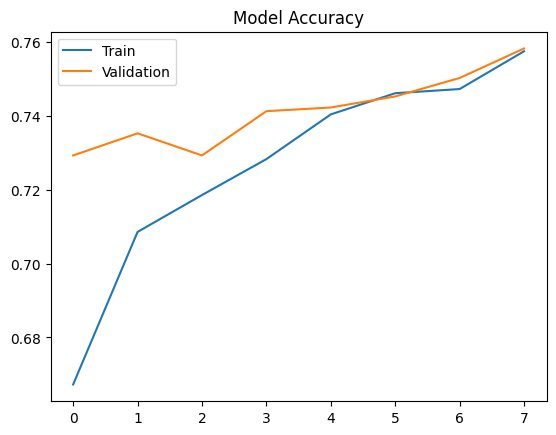

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history_ft.history['accuracy'])
plt.plot(history_ft.history['val_accuracy'])
plt.title('Model Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred)

with open("/content/drive/MyDrive/Dermatology_AI_Project/results/classification_report.txt", "w") as f:
    f.write(report)

print("Classification report saved.")

Classification report saved.


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


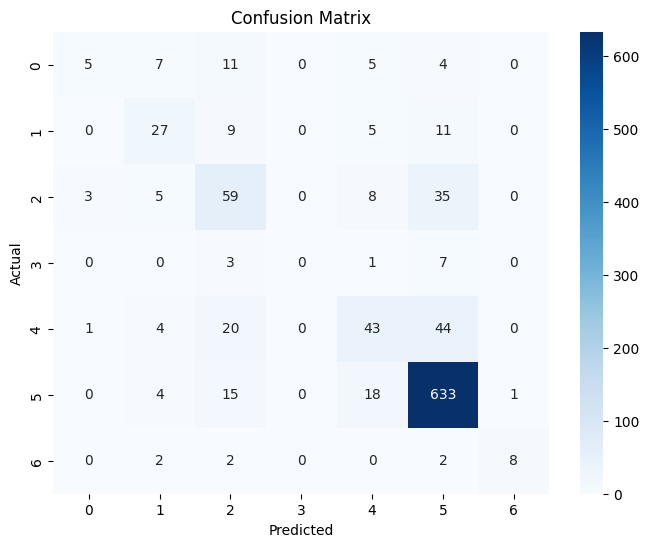

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("/content/drive/MyDrive/Dermatology_AI_Project/results/confusion_matrix.png")
plt.show()

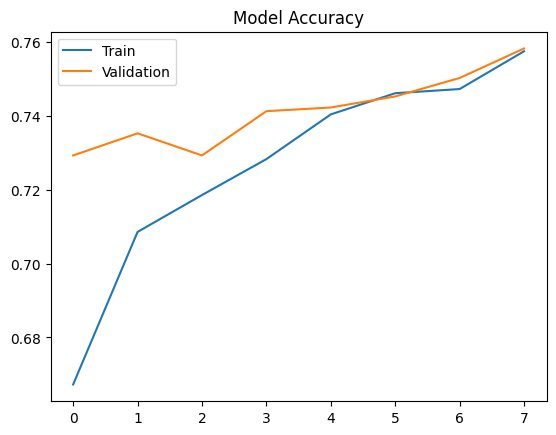

In [ ]:
plt.figure()
plt.plot(history_ft.history['accuracy'])
plt.plot(history_ft.history['val_accuracy'])
plt.title('Model Accuracy')
plt.legend(['Train', 'Validation'])

plt.savefig("/content/drive/MyDrive/Dermatology_AI_Project/results/training_accuracy.png")
plt.show()

In [ ]:
!ls

drive			hmnist_8_8_L.csv
ham10000_images_part_1	hmnist_8_8_RGB.csv
HAM10000_images_part_1	ISIC2018_segmentation.zip
ham10000_images_part_2	ISIC2018_Task1-2_Test_Input
HAM10000_images_part_2	ISIC2018_Task1-2_Training_Input
HAM10000_metadata.csv	ISIC2018_Task1-2_Validation_Input
HAM10000.zip		ISIC2018_Task1_Training_GroundTruth
hmnist_28_28_L.csv	sample_data
hmnist_28_28_RGB.csv


# =========================================
# 🔹 PHASE 2 – LESION SEGMENTATION
# =========================================

Model: U-Net  
Dataset: ISIC 2018  
Objective: Detect and segment lesion regions in dermoscopic images.

## Model Architecture – U-Net

U-Net is a convolutional neural network designed for biomedical image segmentation.

Architecture components:

Encoder:
- Convolution layers
- Downsampling using max pooling

Decoder:
- Upsampling layers
- Skip connections for spatial information recovery

Loss Function:
Binary Cross Entropy + Dice Loss

In [ ]:
import os

train_images_path = "ISIC2018_Task1-2_Training_Input"
train_masks_path = "ISIC2018_Task1_Training_GroundTruth"

print("Images:", len(os.listdir(train_images_path)))
print("Masks:", len(os.listdir(train_masks_path)))

Images: 2596
Masks: 2596


In [ ]:
image_files = sorted(os.listdir(train_images_path))
mask_files = sorted(os.listdir(train_masks_path))

print(image_files[:5])
print(mask_files[:5])

['ATTRIBUTION.txt', 'ISIC_0000000.jpg', 'ISIC_0000001.jpg', 'ISIC_0000003.jpg', 'ISIC_0000004.jpg']
['ATTRIBUTION.txt', 'ISIC_0000000_segmentation.png', 'ISIC_0000001_segmentation.png', 'ISIC_0000003_segmentation.png', 'ISIC_0000004_segmentation.png']


In [ ]:
import os

train_images_path = "ISIC2018_Task1-2_Training_Input"
train_masks_path = "ISIC2018_Task1_Training_GroundTruth"

image_files = sorted([f for f in os.listdir(train_images_path) if f.endswith('.jpg')])
mask_files = sorted([f for f in os.listdir(train_masks_path) if f.endswith('.png')])

print("Total Images:", len(image_files))
print("Total Masks:", len(mask_files))

Total Images: 2594
Total Masks: 2594


In [ ]:
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
import os

IMG_SIZE = 128

X = []
Y = []

for img_name in image_files:

    # Load image
    img_path = os.path.join(train_images_path, img_name)
    img = cv2.imread(img_path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0

    # Load corresponding mask
    mask_name = img_name.replace(".jpg", "_segmentation.png")
    mask_path = os.path.join(train_masks_path, mask_name)

    mask = cv2.imread(mask_path, 0)

    # Use nearest interpolation for masks
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

    # Convert to binary
    mask = (mask > 127).astype(np.float32)

    mask = np.expand_dims(mask, axis=-1)

    X.append(img)
    Y.append(mask)

X = np.array(X)
Y = np.array(Y)

print("Images shape:", X.shape)
print("Masks shape:", Y.shape)

Images shape: (2594, 128, 128, 3)
Masks shape: (2594, 128, 128, 1)


In [ ]:
X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)

Train: (2075, 128, 128, 3)
Validation: (519, 128, 128, 3)


In [ ]:
import tensorflow.keras.backend as K
import tensorflow as tf
from tensorflow.keras import layers, models

# Dice Coefficient (Metric)
def dice_coef(y_true, y_pred):
    smooth = 1.
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return ((2. * intersection + smooth) /
            (K.sum(y_true_f) + K.sum(y_pred_f) + smooth))

# Dice Loss
def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

# BCE + Dice Hybrid Loss
def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

# U-Net
def build_unet(input_shape=(128,128,3)):

    inputs = layers.Input(input_shape)

    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)

    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D()(c3)

    bn = layers.Conv2D(512, 3, activation='relu', padding='same')(p3)
    bn = layers.Conv2D(512, 3, activation='relu', padding='same')(bn)

    u1 = layers.UpSampling2D()(bn)
    u1 = layers.concatenate([u1, c3])
    c4 = layers.Conv2D(256, 3, activation='relu', padding='same')(u1)
    c4 = layers.Conv2D(256, 3, activation='relu', padding='same')(c4)

    u2 = layers.UpSampling2D()(c4)
    u2 = layers.concatenate([u2, c2])
    c5 = layers.Conv2D(128, 3, activation='relu', padding='same')(u2)
    c5 = layers.Conv2D(128, 3, activation='relu', padding='same')(c5)

    u3 = layers.UpSampling2D()(c5)
    u3 = layers.concatenate([u3, c1])
    c6 = layers.Conv2D(64, 3, activation='relu', padding='same')(u3)
    c6 = layers.Conv2D(64, 3, activation='relu', padding='same')(c6)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c6)

    return models.Model(inputs, outputs)

model = build_unet()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=bce_dice_loss,
    metrics=[dice_coef]
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_30 (Conv2D)  │ (None, 128, 128,  │      1,792 │ input_layer_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_31 (Conv2D)  │ (None, 128, 128,  │     36,928 │ conv2d_30[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 64, 64,    │          0 │ conv2d_31[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_32 (Conv2D)  │ (None, 64, 64,    │     73,856 │ max_pooling2d_6[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_33 (Conv2D)  │ (None, 64, 64,    │    147,584 │ conv2d_32[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 32, 32,    │          0 │ conv2d_33[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_34 (Conv2D)  │ (None, 32, 32,    │    295,168 │ max_pooling2d_7[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_35 (Conv2D)  │ (None, 32, 32,    │    590,080 │ conv2d_34[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 16, 16,    │          0 │ conv2d_35[0][0]   │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_36 (Conv2D)  │ (None, 16, 16,    │  1,180,160 │ max_pooling2d_8[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_37 (Conv2D)  │ (None, 16, 16,    │  2,359,808 │ conv2d_36[0][0]   │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_6     │ (None, 32, 32,    │          0 │ conv2d_37[0][0]   │
│ (UpSampling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 32, 32,    │          0 │ up_sampling2d_6[… │
│ (Concatenate)       │ 768)              │            │ conv2d_35[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 32, 32,    │  1,769,728 │ concatenate_6[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 32, 32,    │    590,080 │ conv2d_38[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_7     │ (None, 64, 64,    │          0 │ conv2d_39[0][0] 

 Total params: 7,782,913 (29.69 MB)

 Trainable params: 7,782,913 (29.69 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import numpy as np

print("Unique values:", np.unique(Y))

# Check how many masks are completely empty
empty_masks = np.sum(np.sum(Y, axis=(1,2,3)) == 0)
print("Empty masks:", empty_masks)
print("Total masks:", Y.shape[0])

Unique values: [0. 1.]
Empty masks: 0
Total masks: 2594


In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=30,
    batch_size=16,
    callbacks=[early_stop]
)

Epoch 1/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 25s 192ms/step - dice_coef: 0.7814 - loss: 0.4309 - val_dice_coef: 0.7785 - val_loss: 0.4241
Epoch 2/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 26s 199ms/step - dice_coef: 0.7842 - loss: 0.4124 - val_dice_coef: 0.8031 - val_loss: 0.3883
Epoch 3/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 27s 209ms/step - dice_coef: 0.8013 - loss: 0.3943 - val_dice_coef: 0.7611 - val_loss: 0.4784
Epoch 4/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 26s 199ms/step - dice_coef: 0.8027 - loss: 0.3825 - val_dice_coef: 0.7949 - val_loss: 0.4275
Epoch 5/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 26s 201ms/step - dice_coef: 0.8091 - loss: 0.3712 - val_dice_coef: 0.8250 - val_loss: 0.3757
Epoch 6/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 26s 203ms/step - dice_coef: 0.8171 - loss: 0.3529 - val_dice_coef: 0.8264 - val_loss: 0.3510
Epoch 7/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 26s 201ms/step - dice_coef: 0.8261 - loss: 0.3422 - val_dice_coef: 0.8267 - val_loss: 0.3494
Epoch 8/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 26s 200ms/step - dice_coef: 0

In [ ]:
model.save("/content/drive/MyDrive/Dermatology_AI_Project/models/unet_segmentation_best.keras")

In [ ]:
import os

BASE_PATH = "/content/drive/MyDrive/Dermatology_AI_Project"
NOTEBOOK_PATH = os.path.join(BASE_PATH, "notebooks")

os.makedirs(NOTEBOOK_PATH, exist_ok=True)

print("Notebook folder ready at:", NOTEBOOK_PATH)

Notebook folder ready at: /content/drive/MyDrive/Dermatology_AI_Project/notebooks


In [ ]:
!ls "/content/drive/MyDrive/Colab Notebooks"

'Another copy of DermAI_Phase1_DataPipeline.ipynb'
'Copy of DermAI_Phase1_DataPipeline.ipynb'
'Yet another copy of DermAI_Phase1_DataPipeline.ipynb'


# 📊 Project Results

### Phase 1 – Classification
Final Test Accuracy: **77.34%**

### Phase 2 – Segmentation
Best Validation Dice Score: **0.86**

These results demonstrate the effectiveness of deep learning for dermatology image analysis.

# 🚀 Future Work

Next phase of the project will include:

- Generating **ROI-based images using segmentation masks**
- Training a classifier using lesion-only images
- Comparing performance with the baseline classification model

Expected improvement: **higher classification accuracy and better generalization.**